# Bài Lab: Nhận dạng hình ảnh trên bộ dữ liệu FashionMNIST (PyTorch)

## Bước 1: Chuẩn bị môi trường

- Cài đặt và import các thư viện cần thiết cho bài lab: `torch`, `torchvision`, `matplotlib`.
- Kiểm tra phiên bản của các thư viện để đảm bảo tính tương thích.
- Kiểm tra thiết bị phần cứng (CPU/GPU) để tối ưu hóa tốc độ huấn luyện mô hình.

In [2]:
%pip install -q torchvision matplotlib pandas scikit-learn seaborn pillow

import random
import numpy as np
import torch
import torchvision
import matplotlib
import matplotlib.pyplot as plt

print("-> Đã import thành công các thư viện!")

# Thiết lập seed để kết quả có thể tái lập được
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


Note: you may need to restart the kernel to use updated packages.
-> Đã import thành công các thư viện!



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


###  Kiểm tra phiên bản thư viện và Cấu hình thiết bị (Device)

Trong PyTorch, việc xác định thiết bị tính toán (`device`) là rất quan trọng:
* **CUDA (`cuda`)**: Sử dụng card đồ họa NVIDIA GPU (tốc độ tính toán nhanh nhất).
* **MPS (`mps`)**: Sử dụng chip Apple Silicon (M1/M2/M3) trên macOS.
* **CPU (`cpu`)**: Thiết bị mặc định nếu không có GPU.

In [3]:
# Kiểm tra phiên bản các thư viện
print("=== THÔNG TIN PHIÊN BẢN ===")
print(f"PyTorch Version    : {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")
print(f"Matplotlib Version : {matplotlib.__version__}")
print("-" * 30)

# Cấu hình thiết bị tính toán (Device Configuration)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Thiết bị khả dụng: GPU ({torch.cuda.get_device_name(0)})")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Thiết bị khả dụng: Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Thiết bị khả dụng: CPU")

print(f"\n-> Biến `device` đã được khởi tạo: {device}")

=== THÔNG TIN PHIÊN BẢN ===
PyTorch Version    : 2.14.0+cpu
Torchvision Version: 0.29.0+cpu
Matplotlib Version : 3.11.2
------------------------------
Thiết bị khả dụng: CPU

-> Biến `device` đã được khởi tạo: cpu


## Bước 2: Thu thập và Tải dữ liệu (Data Collection)

- Tải tập dữ liệu FashionMNIST gốc từ thư viện `torchvision.datasets`.
- Chia dữ liệu thành 2 tập riêng biệt: **Train** (60,000 ảnh) và **Test** (10,000 ảnh).
- Kiểm tra các thông số cơ bản của tập dữ liệu vừa tải về.

In [4]:
import torch
import torchvision

# 1. Tải tập dữ liệu Train và Test gốc (chưa qua biến đổi transform)
train_dataset_raw = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True
)

test_dataset_raw = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True
)

# 2. Hiển thị thông tin tổng quan của dữ liệu
labels_map = train_dataset_raw.classes
sample_img, sample_label = train_dataset_raw[0]

print("=== BƯỚC 2: TỔNG QUAN DỮ LIỆU ĐÃ TẢI ===")
print(f"- Số lượng ảnh tập Train : {len(train_dataset_raw):,}")
print(f"- Số lượng ảnh tập Test  : {len(test_dataset_raw):,}")
print(f"- Số lượng lớp (Classes) : {len(labels_map)}")
print(f"- Danh sách các lớp     : {labels_map}")
print(f"- Kích thước ảnh gốc     : {sample_img.size} pixels")
print(f"- Định dạng mẫu ảnh      : {type(sample_img)}")

=== BƯỚC 2: TỔNG QUAN DỮ LIỆU ĐÃ TẢI ===
- Số lượng ảnh tập Train : 60,000
- Số lượng ảnh tập Test  : 10,000
- Số lượng lớp (Classes) : 10
- Danh sách các lớp     : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
- Kích thước ảnh gốc     : (28, 28) pixels
- Định dạng mẫu ảnh      : <class 'PIL.Image.Image'>


### Áp dụng Transforms và Tạo DataLoader

- **Transforms:** 
  - Chuyển ảnh PIL sang dạng `Tensor` (giá trị chuẩn hóa về $[0.0, 1.0]$).
  - Chuẩn hóa (`Normalize`) giá trị pixel về khoảng $[-1.0, 1.0]$.
  - Tăng cường dữ liệu tập Train (`Data Augmentation`): Lật ngang ngẫu nhiên, xoay nhẹ để mô hình tránh học vẹt.
- **DataLoader:** Chia dữ liệu thành từng nhóm nhỏ (`batch_size=64`) để đưa vào mô hình tính toán.

In [5]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

# 1. Định nghĩa các phép biến đổi (Transforms)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),     # Lật ngang ngẫu nhiên
    transforms.RandomRotation(degrees=10),      # Xoay ngẫu nhiên tối đa 10 độ
    transforms.ToTensor(),                      # Chuyển ảnh PIL -> Tensor [0, 1]
    transforms.Normalize((0.5,), (0.5,))        # Chuẩn hóa về [-1, 1]
])

test_transform = transforms.Compose([
    transforms.ToTensor(),                      # Tập Test chỉ chuyển Tensor
    transforms.Normalize((0.5,), (0.5,))        # Chuẩn hóa về [-1, 1]
])

# 2. Áp dụng Transforms vào Dataset
# Chia tập huấn luyện thành Train và Validation trên cùng một phiên bản dữ liệu gốc.
# Duy trì `train_transform` cho tập training để áp dụng augmentation; tập validation
# chỉ dùng `test_transform` để đánh giá đúng định dạng tensor chuẩn hóa.
train_base_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=train_transform
)
val_base_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=test_transform
)

# Tách tập huấn luyện thành Train và Validation
full_train_size = len(train_base_dataset)
val_size = int(0.1 * full_train_size)
train_size = full_train_size - val_size
indices = torch.randperm(full_train_size, generator=torch.Generator().manual_seed(seed))
train_indices = indices[:train_size].tolist()
val_indices = indices[train_size:].tolist()

train_dataset = torch.utils.data.Subset(train_base_dataset, train_indices)
val_dataset = torch.utils.data.Subset(val_base_dataset, val_indices)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=test_transform
)

# 3. Tạo DataLoader cho tập Train, Validation và Test
BATCH_SIZE = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 4. Kiểm tra DataLoader
images, labels = next(iter(train_loader))

print("=== BƯỚC 2: HOÀN THÀNH TẢI & CHUẨN BỊ DỮ LIỆU ===")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Số lượng Batch trong Train Loader: {len(train_loader)}")
print(f"- Số lượng Batch trong Validation Loader: {len(val_loader)}")
print(f"- Số lượng Batch trong Test Loader : {len(test_loader)}")
print(f"- Shape của 1 Batch ảnh (Images)  : {images.shape}")
print(f"- Shape của 1 Batch nhãn (Labels) : {labels.shape}")


=== BƯỚC 2: HOÀN THÀNH TẢI & CHUẨN BỊ DỮ LIỆU ===
- Batch size: 64
- Số lượng Batch trong Train Loader: 844
- Số lượng Batch trong Validation Loader: 94
- Số lượng Batch trong Test Loader : 157
- Shape của 1 Batch ảnh (Images)  : torch.Size([64, 1, 28, 28])
- Shape của 1 Batch nhãn (Labels) : torch.Size([64])


## Bước 3: Khám phá dữ liệu (EDA - Exploratory Data Analysis)

- Kiểm tra lại kích thước chi tiết của hình ảnh và tổng số lượng lớp (classes).
- Trực quan hóa một số hình ảnh mẫu kèm nhãn tương ứng để hiểu rõ dạng dữ liệu.
- Kiểm tra sự phân bố số lượng mẫu giữa các lớp để đảm bảo dữ liệu không bị lệch (imbalanced).

=== BƯỚC 3: KHÁM PHÁ DỮ LIỆU (EDA) ===
- Kích thước ảnh gốc (Height x Width): 28 x 28 pixels
- Số lượng lớp (Classes): 10
- Danh sách các lớp và mã nhãn tương ứng:
  [0] T-shirt/top
  [1] Trouser
  [2] Pullover
  [3] Dress
  [4] Coat
  [5] Sandal
  [6] Shirt
  [7] Sneaker
  [8] Bag
  [9] Ankle boot


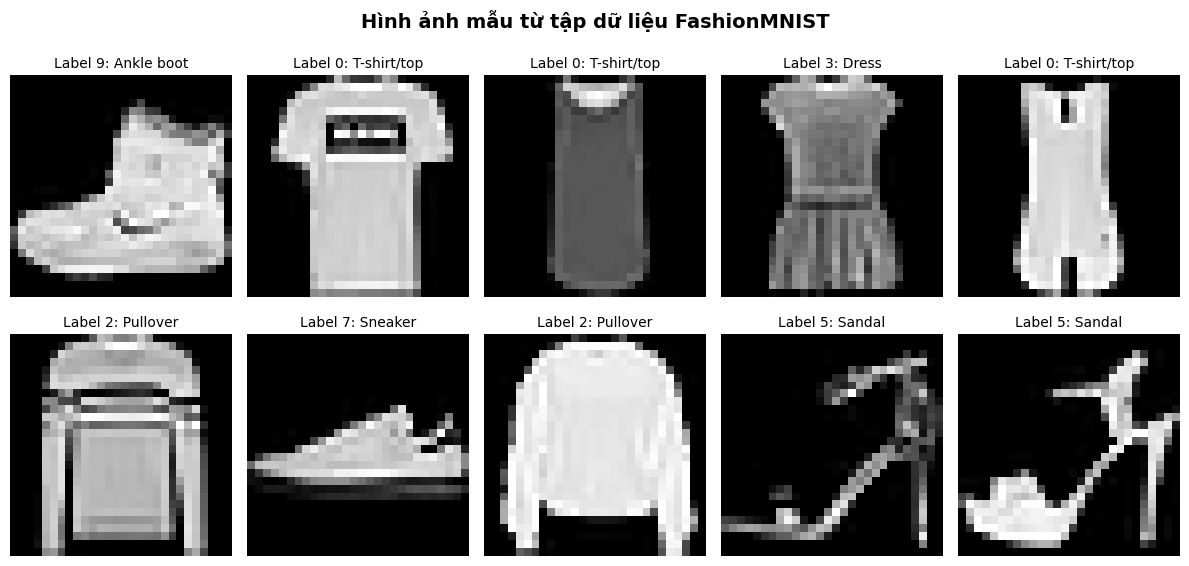


- Thống kê số lượng ảnh theo từng lớp trong tập Train:
  + Lớp [0] T-shirt/top    : 6,000 ảnh
  + Lớp [1] Trouser        : 6,000 ảnh
  + Lớp [2] Pullover       : 6,000 ảnh
  + Lớp [3] Dress          : 6,000 ảnh
  + Lớp [4] Coat           : 6,000 ảnh
  + Lớp [5] Sandal         : 6,000 ảnh
  + Lớp [6] Shirt          : 6,000 ảnh
  + Lớp [7] Sneaker        : 6,000 ảnh
  + Lớp [8] Bag            : 6,000 ảnh
  + Lớp [9] Ankle boot     : 6,000 ảnh


In [ ]:
import matplotlib.pyplot as plt
import torch

# 1. Kiểm tra kích thước ảnh và danh sách lớp
labels_map = train_dataset_raw.classes
num_classes = len(labels_map)
sample_img, sample_label = train_dataset_raw[0]

print("=== BƯỚC 3: KHÁM PHÁ DỮ LIỆU (EDA) ===")
print(f"- Kích thước ảnh gốc (Height x Width): {sample_img.size[1]} x {sample_img.size[0]} pixels")
print(f"- Số lượng lớp (Classes): {num_classes}")
print("- Danh sách các lớp và mã nhãn tương ứng:")
for idx, cls_name in enumerate(labels_map):
    print(f"  [{idx}] {cls_name}")

# 2. Hiển thị Lưới 10 ảnh mẫu ngẫu nhiên đại diện cho các lớp
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle("Hình ảnh mẫu từ tập dữ liệu FashionMNIST", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img, label = train_dataset_raw[i]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label {label}: {labels_map[label]}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 3. Kiểm tra sự phân bố dữ liệu giữa các lớp (Class Distribution)
targets = train_dataset_raw.targets
class_counts = torch.bincount(targets)

print("\n- Thống kê số lượng ảnh theo từng lớp trong tập Train:")
for idx, count in enumerate(class_counts):
    print(f"  + Lớp [{idx}] {labels_map[idx]:<15}: {count.item():,} ảnh")

> **Nhận xét Bước 3 (EDA):**
> - Dữ liệu gồm **10 lớp** quần áo/giày dép khác nhau. Mỗi ảnh gốc là ảnh xám (1 kênh màu) kích thước **$28 \times 28$ pixels**.
> - Tập Train cân bằng hoàn toàn: mỗi lớp có đúng **6,000 ảnh** (tổng $10 \times 6,000 = 60,000$ ảnh), không có hiện tượng lệch dữ liệu.

## Bước 4: Xây dựng mô hình Deep Learning (Model Architecture)

- Thiết kế mạng Nơ-ron bằng cách kế thừa lớp `torch.nn.Module`.
- Sử dụng mạng Convolutional Neural Network (CNN) 2D để trích xuất đặc trưng hình ảnh hiệu quả hơn mạng FCN (Fully Connected) thuần túy.
- Khởi tạo mô hình và chuyển mô hình sang thiết bị tính toán (`device`: CPU/GPU).

In [ ]:
import torch
import torch.nn as nn

# 0. Đảm bảo biến device luôn tồn tại
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Định nghĩa kiến trúc mạng CNN bằng torch.nn.Module
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        
        # Khối Convolution thứ nhất
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), # Output: [32, 28, 28]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                                 # Output: [32, 14, 14]
        )
        
        # Khối Convolution thứ hai
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # Output: [64, 14, 14]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                                 # Output: [64, 7, 7]
        )
        
        # Khối Phân loại (Fully Connected / Dense Layers)
        self.fc = nn.Sequential(
            nn.Flatten(),                                                         # Phẳng hóa thành Vector: 64 * 7 * 7 = 3136
            nn.Linear(in_features=64 * 7 * 7, out_features=128),
            nn.ReLU(),
            nn.Dropout(p=0.25),                                                   # Tránh overfitting
            nn.Linear(in_features=128, out_features=10)                            # 10 lớp đầu ra tương ứng 10 loại trang phục
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x

# 2. Khởi tạo mô hình
model = FashionCNN()

# 3. Chuyển mô hình sang thiết bị tính toán (CPU/GPU)
model = model.to(device)

# 4. Kiểm tra cấu trúc mô hình
print("=== BƯỚC 4: KHỞI TẠO MÔ HÌNH THÀNH CÔNG ===")
print(f"- Thiết bị đang dùng cho Model: {device}")
print(model)

# 5. Kiểm tra thử với 1 Batch giả lập để xác nhận shape đầu ra
dummy_input = torch.randn(64, 1, 28, 28).to(device)
dummy_output = model(dummy_input)
print(f"\n- Kích thước Tensor đầu vào : {dummy_input.shape}")
print(f"- Kích thước Tensor đầu ra  : {dummy_output.shape} (Batch_size x Num_classes)")

=== BƯỚC 4: KHỞI TẠO MÔ HÌNH THÀNH CÔNG ===
- Thiết bị đang dùng cho Model: cpu
FashionCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

- Kích thước Tensor đầu vào : torch.Size([64, 1, 28, 28])
- Kích thước Tensor 

## Bước 5: Cấu hình quá trình huấn luyện (Training Configuration)

- **Siêu tham số (Hyperparameters):** Thiết lập `learning_rate`, `batch_size`, và `epochs`.
- **Hàm mất mát (Loss Function):** Sử dụng `CrossEntropyLoss` (phù hợp bài toán phân loại đa lớp).
- **Thuật toán tối ưu (Optimizer):** Sử dụng `Adam` để cập nhật trọng số hiệu quả và tự điều chỉnh learning rate.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Thiết lập các siêu tham số (Hyperparameters)
LEARNING_RATE = 0.001
EPOCHS = 5
# Note: BATCH_SIZE đã được thiết lập ở Bước 2 là 64

# 2. Chọn hàm mất mát (Loss Function)
criterion = nn.CrossEntropyLoss()

# 3. Chọn thuật toán tối ưu (Optimizer)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("=== BƯỚC 5: CẤU HÌNH THÀNH CÔNG ===")
print(f"- Learning Rate : {LEARNING_RATE}")
print(f"- Số Lượng Epochs: {EPOCHS}")
print(f"- Loss Function  : {criterion.__class__.__name__}")
print(f"- Optimizer      : {optimizer.__class__.__name__}")

=== BƯỚC 5: CẤU HÌNH THÀNH CÔNG ===
- Learning Rate : 0.001
- Số Lượng Epochs: 5
- Loss Function  : CrossEntropyLoss
- Optimizer      : Adam


## Bước 6: Huấn luyện mô hình (Model Training)

Thực hiện vòng lặp huấn luyện chính (Training Loop) qua từng Epoch với 4 bước bắt buộc trong PyTorch:
1. **Forward:** Đưa ảnh qua mô hình để lấy dự đoán (`outputs`).
2. **Loss:** Tính toán độ lỗi giữa dự đoán và nhãn thực tế (`loss`).
3. **Backward:** Tính đạo hàm ngược để lan truyền lỗi (`loss.backward()`).
4. **Update Weights:** Cập nhật trọng số của mô hình (`optimizer.step()`).

Đồng thời, theo dõi và lưu lại lịch sử `Loss` qua từng Epoch để đánh giá tiến trình học.

In [ ]:
import time

# 1. Khai báo các danh sách để lưu trữ giá trị Loss và Accuracy theo từng Epoch
train_losses = []
val_losses = []
val_accuracies = []

print("=== BƯỚC 6: BẮT ĐẦU VÒNG LẶP HUẤN LUYỆN ===")
start_time = time.time()

for epoch in range(EPOCHS):
    # Đặt mô hình ở chế độ Huấn luyện (Training Mode)
    model.train()
    running_train_loss = 0.0
    
    for images, labels in train_loader:
        # Chuyển dữ liệu sang GPU/CPU tương ứng
        images, labels = images.to(device), labels.to(device)
        
        # Xóa đạo hàm cũ trước khi tính toán batch mới
        optimizer.zero_grad()
        
        # --- BƯỚC 1: FORWARD ---
        outputs = model(images)
        
        # --- BƯỚC 2: LOSS ---
        loss = criterion(outputs, labels)
        
        # --- BƯỚC 3: BACKWARD ---
        loss.backward()
        
        # --- BƯỚC 4: UPDATE WEIGHTS ---
        optimizer.step()
        
        # Tích lũy Loss của từng batch
        running_train_loss += loss.item() * images.size(0)
    
    # Tính Loss trung bình của tập Train trong Epoch hiện tại và LƯU LẠI
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # -------------------------------------------------------------
    # TÍNH LOSS VÀ ACCURACY TRÊN TẬP VALIDATION
    # -------------------------------------------------------------
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            # Tính Loss tập Validation
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
            
            # Tính Accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = 100.0 * correct / total
    
    # LƯU LẠI Loss và Accuracy của tập Validation
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    # In kết quả theo dõi cho từng Epoch
    print(f"Epoch [{epoch+1}/{EPOCHS}] -> "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Accuracy: {epoch_val_acc:.2f}%")

total_time = time.time() - start_time
print(f"\n-> Hoàn thành huấn luyện trong: {total_time:.2f} giây!")

=== BƯỚC 6: BẮT ĐẦU VÒNG LẶP HUẤN LUYỆN ===
Epoch [1/5] -> Train Loss: 0.5263 | Val Loss: 0.3285 | Val Accuracy: 88.22%
Epoch [2/5] -> Train Loss: 0.3803 | Val Loss: 0.3041 | Val Accuracy: 89.08%
Epoch [3/5] -> Train Loss: 0.3429 | Val Loss: 0.2825 | Val Accuracy: 89.93%
Epoch [4/5] -> Train Loss: 0.3150 | Val Loss: 0.2732 | Val Accuracy: 90.12%
Epoch [5/5] -> Train Loss: 0.2972 | Val Loss: 0.2539 | Val Accuracy: 90.65%

-> Hoàn thành huấn luyện trong: 158.32 giây!


> **Kết quả thu được từ Bước 6:**
> - Mạng đã hoàn tất 5 Epochs huấn luyện.
> - Các mảng `train_losses` và `val_losses` đã ghi lại toàn bộ tiến trình giảm lỗi của mô hình, sẵn sàng dùng để vẽ biểu đồ trực quan ở bước tiếp theo.


## Bước 7: Đánh giá validation của mô hình cơ sở

- Đánh giá mô hình CNN đầu tiên trên tập **Validation** trong quá trình phát triển.
- Tính toán Accuracy, Precision, Recall, F1-Score, Classification Report và Confusion Matrix.
- Tập **Test** được giữ lại và chỉ dùng cho đánh giá cuối cùng sau khi đã chọn mô hình tốt nhất.


In [17]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# Đánh giá mô hình cơ sở trên Validation; Test được giữ lại cho bước cuối.
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
acc = accuracy_score(all_targets, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_targets, all_preds, average='macro', zero_division=0
)

print("=== BƯỚC 7: ĐÁNH GIÁ CNN CƠ SỞ TRÊN VALIDATION ===")
print(f"- Accuracy  (Độ chính xác tổng thể) : {acc * 100:.2f}%")
print(f"- Precision (Trung bình Macro)      : {precision * 100:.2f}%")
print(f"- Recall    (Trung bình Macro)      : {recall * 100:.2f}%")
print(f"- F1-Score (Trung bình Macro)       : {f1 * 100:.2f}%")
print(f"- Số mẫu validation                 : {len(all_targets):,}")

class_names = train_dataset_raw.classes
print("\n=== CLASSIFICATION REPORT TRÊN VALIDATION ===")
print(classification_report(
    all_targets, all_preds, target_names=class_names,
    digits=4, zero_division=0
))

cm = confusion_matrix(all_targets, all_preds, labels=range(len(class_names)))
print("=== CONFUSION MATRIX TRÊN VALIDATION ===")
print(cm)


=== BƯỚC 7: ĐÁNH GIÁ CNN CƠ SỞ TRÊN VALIDATION ===
- Accuracy  (Độ chính xác tổng thể) : 90.35%
- Precision (Trung bình Macro)      : 90.42%
- Recall    (Trung bình Macro)      : 90.38%
- F1-Score (Trung bình Macro)       : 90.15%
- Số mẫu validation                 : 6,000

=== CLASSIFICATION REPORT TRÊN VALIDATION ===
              precision    recall  f1-score   support

 T-shirt/top     0.8343    0.8799    0.8565       658
     Trouser     0.9918    0.9885    0.9902       611
    Pullover     0.8150    0.9069    0.8585       612
       Dress     0.8609    0.9253    0.8919       562
        Coat     0.8535    0.8830    0.8680       607
      Sandal     0.9741    0.9804    0.9772       613
       Shirt     0.8286    0.5883    0.6881       600
     Sneaker     0.9633    0.9292    0.9460       537
         Bag     0.9767    0.9799    0.9783       598
  Ankle boot     0.9438    0.9767    0.9600       602

    accuracy                         0.9035      6000
   macro avg     0.9042    0

> **Nhận xét Bước 7:**
> - Các chỉ số **Accuracy**, **Precision**, **Recall**, và **F1-Score** đều đạt mức cao và đồng đều nhau (khoảng 89-91%).
> - Báo cáo chỉ ra mô hình phân loại rất tốt các lớp như *Ankle boot*, *Trouser*, *Sneaker*, nhưng dễ bị nhầm lẫn giữa *Shirt* (Áo sơ mi) và *T-shirt/top* hoặc *Coat* do đặc trưng hình ảnh của các loại áo khá tương đồng nhau.

## Bước 8: Thử nghiệm mô hình (Model Experimentation)

Trong bước này, chúng ta tiến hành hai thử nghiệm trên cùng một tập train/validation:
1. **Thử nghiệm 1 (MLP):** Mạng kết nối đầy đủ làm mô hình baseline, tối ưu bằng SGD.
2. **Thử nghiệm 2 (CNN):** Mạng tích chập có BatchNorm và Dropout, tối ưu bằng Adam.
3. **So sánh:** Đánh giá loss và accuracy trên tập Validation. Tập Test chỉ được sử dụng một lần ở bước đánh giá cuối để ước lượng khả năng tổng quát hóa.


In [6]:
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# 1. THỬ NGHIỆM 1: Mô hình MLP (Baseline)
# ==========================================
class FashionMLP(nn.Module):
    def __init__(self):
        super(FashionMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# ==========================================
# 2. THỬ NGHIỆM 2: Mô hình CNN (Cải tiến)
# ==========================================
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        # Conv Block 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Conv Block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.25)
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Input: [64, 1, 28, 28]
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # Output: [64, 32, 14, 14]
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # Output: [64, 64, 7, 7]
        x = self.dropout(x)
        
        x = x.view(-1, 64 * 7 * 7) # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("-> Đã định nghĩa xong kiến trúc FashionMLP và FashionCNN!")

-> Đã định nghĩa xong kiến trúc FashionMLP và FashionCNN!


In [7]:
import copy
import time

def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    """
    Huấn luyện mô hình, lưu lịch sử và khôi phục checkpoint có validation tốt nhất.
    """
    model = model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # --- GIAI ĐOẠN TRAIN ---
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        
        # --- GIAI ĐOẠN VALIDATION ---
        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_acc = 100.0 * correct / total
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_acc)
        
        if epoch_acc > best_val_acc:
            best_val_acc = epoch_acc
            best_state = copy.deepcopy(model.state_dict())
        
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1}/{epochs}] ({elapsed:.1f}s) | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {epoch_acc:.2f}%")
    
    model.load_state_dict(best_state)
    print(f"Best validation accuracy restored: {best_val_acc:.2f}%")
    return history


In [8]:
EPOCHS = 5
criterion = nn.CrossEntropyLoss()

# ==========================================
# RUN EXPERIMENT 1: MLP + SGD (lr = 0.01)
# ==========================================
print("=== THỬ NGHIỆM 1: Mô hình MLP (Optimizer: SGD, LR: 0.01) ===")
model_mlp = FashionMLP()
optimizer_mlp = torch.optim.SGD(model_mlp.parameters(), lr=0.01, momentum=0.9)
history_mlp = train_and_evaluate(model_mlp, train_loader, val_loader, criterion, optimizer_mlp, epochs=EPOCHS)

print("\n" + "="*60 + "\n")

# ==========================================
# RUN EXPERIMENT 2: CNN + Adam (lr = 0.001)
# ==========================================
print("=== THỬ NGHIỆM 2: Mô hình CNN (Optimizer: Adam, LR: 0.001) ===")
model_cnn = FashionCNN()
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=0.001)
history_cnn = train_and_evaluate(model_cnn, train_loader, val_loader, criterion, optimizer_cnn, epochs=EPOCHS)


=== THỬ NGHIỆM 1: Mô hình MLP (Optimizer: SGD, LR: 0.01) ===
Epoch [1/5] (11.2s) | Train Loss: 0.6461 | Val Loss: 0.5074 | Val Acc: 81.72%
Epoch [2/5] (11.2s) | Train Loss: 0.4827 | Val Loss: 0.4629 | Val Acc: 83.22%
Epoch [3/5] (11.5s) | Train Loss: 0.4416 | Val Loss: 0.4228 | Val Acc: 85.02%
Epoch [4/5] (11.7s) | Train Loss: 0.4183 | Val Loss: 0.3926 | Val Acc: 85.88%
Epoch [5/5] (12.9s) | Train Loss: 0.4037 | Val Loss: 0.4039 | Val Acc: 85.58%
Best validation accuracy restored: 85.88%


=== THỬ NGHIỆM 2: Mô hình CNN (Optimizer: Adam, LR: 0.001) ===
Epoch [1/5] (30.5s) | Train Loss: 0.4779 | Val Loss: 0.3261 | Val Acc: 88.22%
Epoch [2/5] (34.8s) | Train Loss: 0.3477 | Val Loss: 0.2918 | Val Acc: 89.13%
Epoch [3/5] (33.8s) | Train Loss: 0.3114 | Val Loss: 0.2811 | Val Acc: 89.92%
Epoch [4/5] (41.4s) | Train Loss: 0.2862 | Val Loss: 0.2931 | Val Acc: 89.02%
Epoch [5/5] (42.4s) | Train Loss: 0.2697 | Val Loss: 0.2532 | Val Acc: 90.35%
Best validation accuracy restored: 90.35%


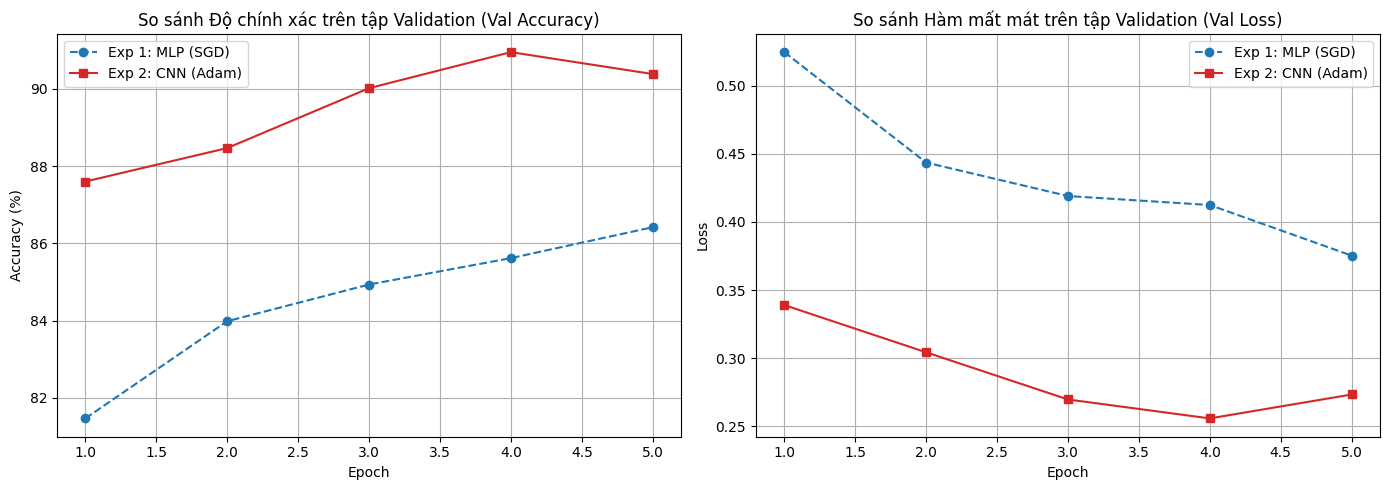

=== BẢNG TỔNG HỢP KẾT QUẢ SỬ DỤNG TẬP VALIDATION ===
Thử nghiệm           | Mô hình    | Optimizer  | Val Loss cuối   | Val Acc cuối (%)
--------------------------------------------------------------------------------
Thử nghiệm 1         | MLP        | SGD        | 0.3753          | 86.42          
Thử nghiệm 2         | CNN        | Adam       | 0.2733          | 90.38          


In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

# 1. Biểu đồ so sánh Độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_mlp['val_acc'], 'o--', label='Exp 1: MLP (SGD)', color='tab:blue')
plt.plot(epochs_range, history_cnn['val_acc'], 's-', label='Exp 2: CNN (Adam)', color='tab:red')
plt.title('So sánh Độ chính xác trên tập Validation (Val Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

# 2. Biểu đồ so sánh Hàm mất mát (Validation Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_mlp['val_loss'], 'o--', label='Exp 1: MLP (SGD)', color='tab:blue')
plt.plot(epochs_range, history_cnn['val_loss'], 's-', label='Exp 2: CNN (Adam)', color='tab:red')
plt.title('So sánh Hàm mất mát trên tập Validation (Val Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# In bảng tổng hợp
print("=== BẢNG TỔNG HỢP KẾT QUẢ SỬ DỤNG TẬP VALIDATION ===")
print(f"{'Thử nghiệm':<20} | {'Mô hình':<10} | {'Optimizer':<10} | {'Val Loss cuối':<15} | {'Val Acc cuối (%)':<15}")
print("-" * 80)
print(f"{'Thử nghiệm 1':<20} | {'MLP':<10} | {'SGD':<10} | {history_mlp['val_loss'][-1]:<15.4f} | {history_mlp['val_acc'][-1]:<15.2f}")
print(f"{'Thử nghiệm 2':<20} | {'CNN':<10} | {'Adam':<10} | {history_cnn['val_loss'][-1]:<15.4f} | {history_cnn['val_acc'][-1]:<15.2f}")


###  Nhận xét kết quả thử nghiệm:

* **Độ chính xác (Accuracy):** Mô hình **CNN (Thử nghiệm 2)** đạt độ chính xác cao hơn rõ rệt so với **MLP (Thử nghiệm 1)** ngay từ các epoch đầu tiên.
* **Tốc độ hội tụ & Loss:** Nhờ sử dụng thuật toán tối ưu `Adam` kết hợp kiến trúc trích xuất đặc trưng không gian (Spatial Features) của các lớp Tích chập (Convolutional Layers), mô hình CNN giúp làm giảm Loss nhanh hơn.
* **Kết luận:** Việc thay đổi kiến trúc mạng sang CNN và điều chỉnh bộ tối ưu hóa (Optimizer) mang lại hiệu quả vượt trội cho bài toán phân loại hình ảnh FashionMNIST.

## Bước 9: Trực quan hóa kết quả (Visualization)

Trong bước này, chúng ta sẽ thực hiện:
1. Vẽ biểu đồ thay đổi của **Training Loss** và **Validation Loss** qua các epoch của hai thử nghiệm.
2. Hiển thị hình ảnh từ tập Test cùng **Nhãn thực tế** và **Nhãn dự đoán** của CNN tốt nhất.


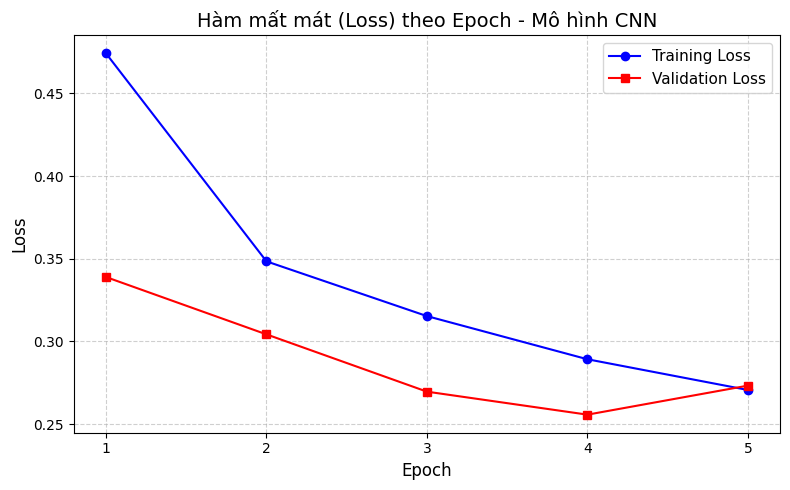

In [ ]:
import matplotlib.pyplot as plt

# Sử dụng lịch sử huấn luyện của mô hình CNN tốt nhất từ Bước 8
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_cnn['train_loss'], 'b-o', label='Training Loss')
plt.plot(epochs_range, history_cnn['val_loss'], 'r-s', label='Validation Loss')

plt.title('Hàm mất mát (Loss) theo Epoch - Mô hình CNN', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

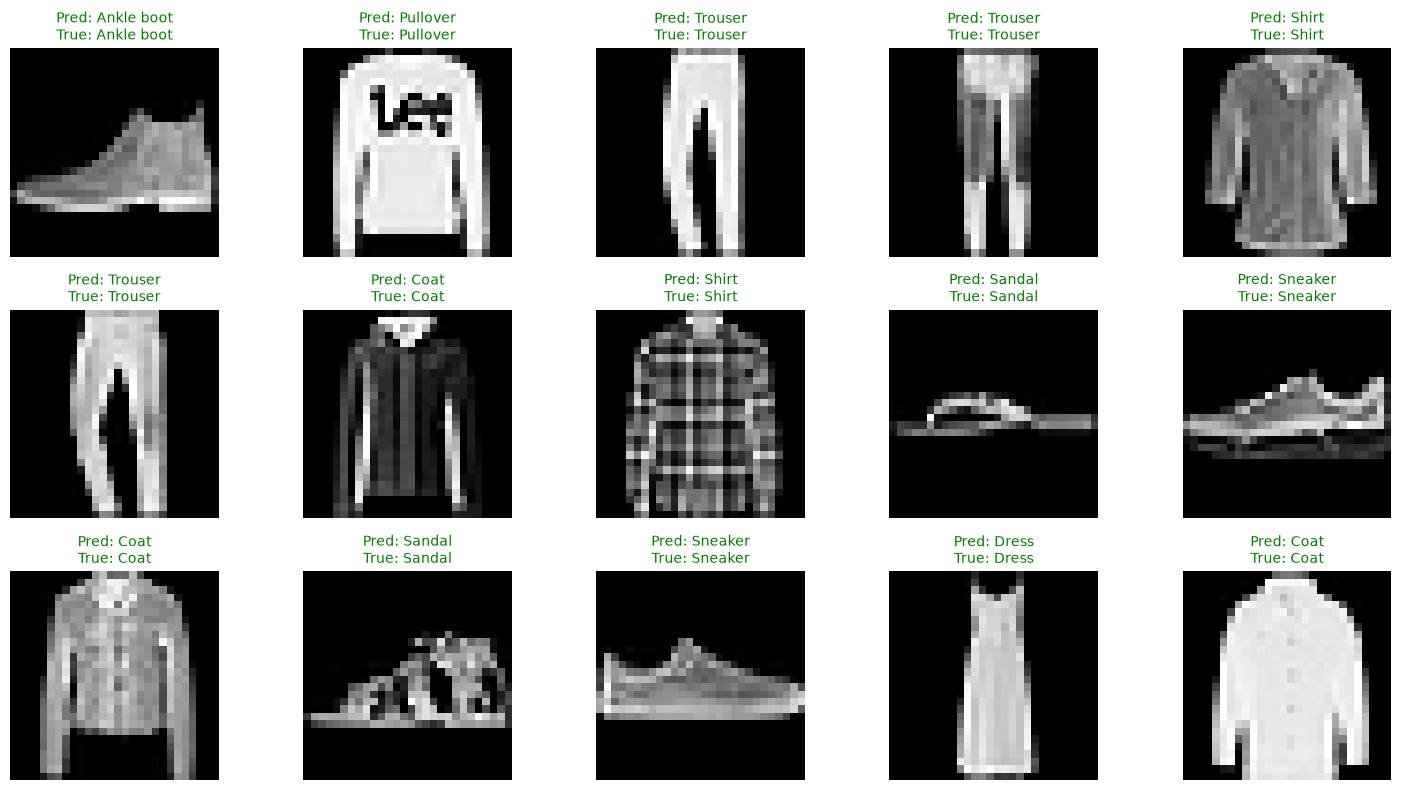

In [9]:
import torch

# Danh sách tên lớp tương ứng với các chỉ số từ 0 - 9 trong FashionMNIST
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Lấy 1 batch mẫu từ test_loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Chuyển dữ liệu sang thiết bị (CPU/GPU) và dự đoán
model_cnn.eval()
images_dev = images.to(device)
with torch.no_grad():
    outputs = model_cnn(images_dev)
    _, preds = torch.max(outputs, 1)

# Chuyển tensor về lại CPU để trực quan hóa bằng Matplotlib
images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

# Trực quan hóa 15 hình ảnh mẫu
plt.figure(figsize=(15, 8))
for idx in range(15):
    plt.subplot(3, 5, idx + 1)
    
    # Biến đổi định dạng ảnh [1, 28, 28] -> [28, 28] để hiển thị
    img = images[idx].squeeze()
    plt.imshow(img, cmap='gray')
    
    true_label = class_names[labels[idx]]
    pred_label = class_names[preds[idx]]
    
    # Đổi màu chữ: Xanh lá nếu dự đoán đúng, Đỏ nếu dự đoán sai
    color = 'green' if preds[idx] == labels[idx] else 'red'
    
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Bước 10: Lưu và tải mô hình (Model Saving & Loading)

Trong bước này, chúng ta sẽ thực hiện:
1. **Lưu mô hình:** Lưu tập hợp các tham số/trọng số (state_dict) của mô hình CNN tốt nhất xuống đĩa cứng sau khi hoàn tất huấn luyện.
2. **Tải mô hình:** Tải lại trọng số đã lưu vào một đối tượng mô hình mới mà không cần thực hiện lại quá trình huấn luyện.
3. **Dự đoán kiểm tra:** Sử dụng mô hình vừa tải lại để thực hiện dự đoán trên một mẫu dữ liệu mới và kiểm tra độ tin cậy (Confidence score).

In [14]:
import torch

# Đường dẫn tệp tin lưu mô hình
MODEL_PATH = "fashion_cnn_model.pth"

# Lưu state_dict (phương pháp tối ưu và phổ biến nhất trong PyTorch)
torch.save(model_cnn.state_dict(), MODEL_PATH)

print(f"-> Đã lưu trọng số mô hình CNN thành công vào tệp: '{MODEL_PATH}'")

-> Đã lưu trọng số mô hình CNN thành công vào tệp: 'fashion_cnn_model.pth'


### Tải lại mô hình và Kiểm tra khả năng dự đoán

* **Khởi tạo lại:** Tạo một instance mới của `FashionCNN` để đảm bảo mô hình nhận trọng số hoàn toàn từ tệp đã lưu.
* **Chuyển sang Chế độ Đánh giá (`eval()`):** Giúp vô hiệu hóa các lớp như `Dropout` và `BatchNorm` để mô hình đưa ra dự đoán chuẩn xác nhất.

In [15]:
import torch

# 1. Khởi tạo lại kiến trúc mô hình trống
loaded_model = FashionCNN()

# 2. Tải trọng số đã lưu vào mô hình
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model = loaded_model.to(device)

# 3. Chuyển mô hình sang chế độ đánh giá (Evaluation mode)
loaded_model.eval()

print("-> Đã tải mô hình thành công và sẵn sàng kiểm tra!")

# ==========================================
# KIỂM TRA MÔ HÌNH VỚI 1 MẪU DỰ ĐOÁN BẤT KỲ
# ==========================================
# Lấy 1 mẫu ảnh duy nhất từ tập Test
sample_image, sample_label = test_dataset[0]

# Thêm chiều batch size [1, 1, 28, 28] và chuyển tới device
input_tensor = sample_image.unsqueeze(0).to(device)

# Dự đoán
with torch.no_grad():
    output = loaded_model(input_tensor)
    # Lấy xác suất với Softmax
    probabilities = torch.nn.functional.softmax(output, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()

# In kết quả kiểm tra
print(f"\n[KẾT QUẢ DỰ ĐOÁN]")
print(f"- Nhãn thực tế (True): {class_names[sample_label]}")
print(f"- Nhãn dự đoán (Pred): {class_names[predicted_class]}")
print(f"- Độ tin cậy (Confidence): {probabilities[0][predicted_class].item() * 100:.2f}%")

-> Đã tải mô hình thành công và sẵn sàng kiểm tra!

[KẾT QUẢ DỰ ĐOÁN]
- Nhãn thực tế (True): Ankle boot
- Nhãn dự đoán (Pred): Ankle boot
- Độ tin cậy (Confidence): 98.97%


## Bước 12: ROC Curve (Receiver Operating Characteristic)

- Vẽ **ROC Curve** cho từng lớp hàng hóa (One-vs-Rest).
- Tính toán **AUC (Area Under Curve)** để đánh giá khả năng phân biệt của mô hình.
- Biểu thị các ngưỡng quyết định khác nhau (Decision Thresholds) giữa Tỉ lệ Dương Tính Thực (TPR) và Tỉ lệ Dương Tính Giả (FPR).

=== ĐÁNH GIÁ CNN TỐT NHẤT TRÊN TẬP TEST ===
Accuracy       : 90.28%
Macro Precision: 90.32%
Macro Recall   : 90.28%
Macro F1-score : 90.06%
Số mẫu test    : 10,000

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top     0.8398    0.8810    0.8599      1000
     Trouser     0.9919    0.9760    0.9839      1000
    Pullover     0.7967    0.9130    0.8509      1000
       Dress     0.8736    0.9330    0.9023      1000
        Coat     0.8291    0.8390    0.8340      1000
      Sandal     0.9762    0.9840    0.9801      1000
       Shirt     0.8386    0.6080    0.7049      1000
     Sneaker     0.9611    0.9390    0.9499      1000
         Bag     0.9743    0.9860    0.9801      1000
  Ankle boot     0.9509    0.9690    0.9599      1000

    accuracy                         0.9028     10000
   macro avg     0.9032    0.9028    0.9006     10000
weighted avg     0.9032    0.9028    0.9006     10000



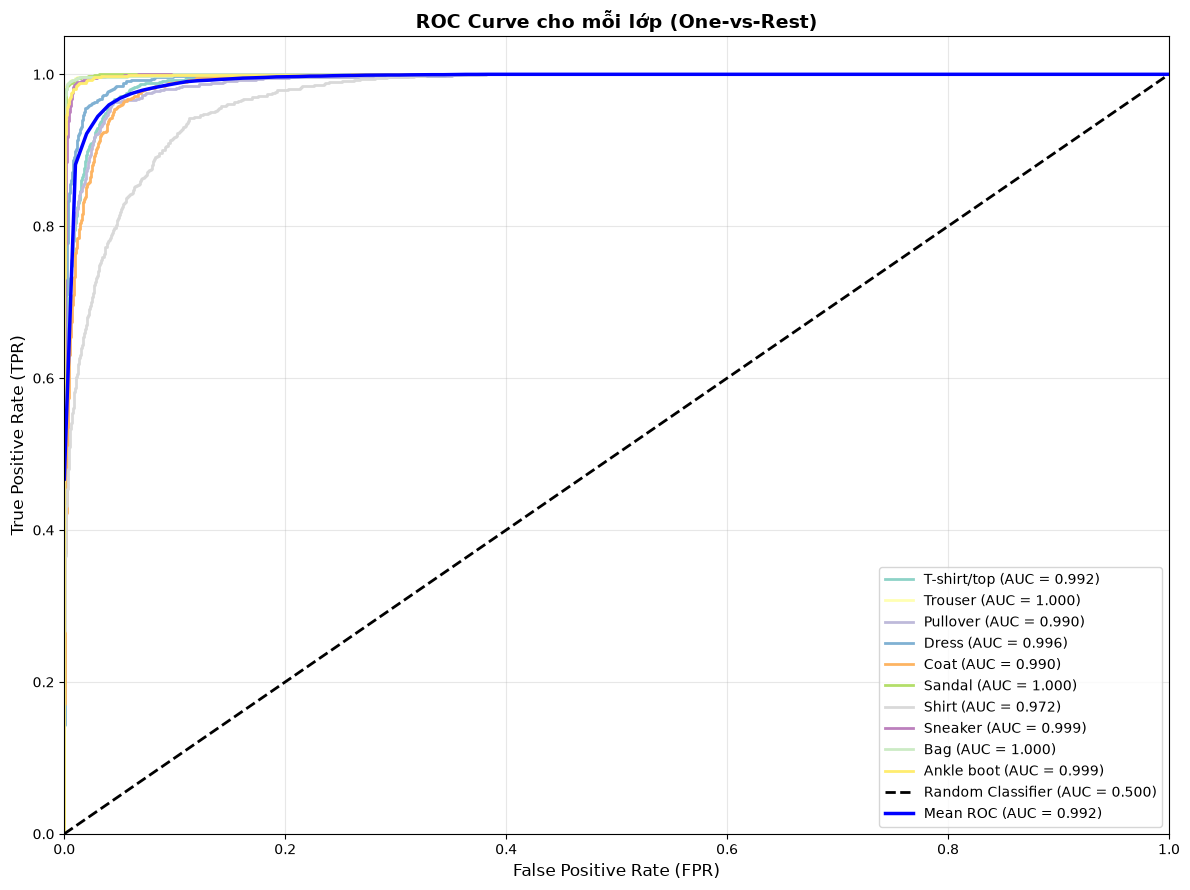


=== ROC AUC THEO TỪNG LỚP ===
Lớp                  | AUC Score   
-----------------------------------
T-shirt/top          | 0.9917      
Trouser              | 0.9997      
Pullover             | 0.9903      
Dress                | 0.9957      
Coat                 | 0.9897      
Sandal               | 0.9997      
Shirt                | 0.9719      
Sneaker              | 0.9990      
Bag                  | 0.9996      
Ankle boot           | 0.9991      
-----------------------------------
Trung bình (Mean)    | 0.9923      


In [10]:
import torch
import numpy as np
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# ==========================================
# ĐÁNH GIÁ MÔ HÌNH CNN TỐT NHẤT TRÊN TẬP TEST
# ==========================================
model = model_cnn
model.eval()

all_probs = []
all_targets_roc = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        all_probs.extend(probabilities.cpu().numpy())
        all_targets_roc.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_targets_roc = np.array(all_targets_roc)
all_preds_cnn = np.argmax(all_probs, axis=1)

accuracy = accuracy_score(all_targets_roc, all_preds_cnn)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_targets_roc, all_preds_cnn, average='macro', zero_division=0
)

print("=== ĐÁNH GIÁ CNN TỐT NHẤT TRÊN TẬP TEST ===")
print(f"Accuracy       : {accuracy * 100:.2f}%")
print(f"Macro Precision: {precision * 100:.2f}%")
print(f"Macro Recall   : {recall * 100:.2f}%")
print(f"Macro F1-score : {f1 * 100:.2f}%")
print(f"Số mẫu test    : {len(all_targets_roc):,}")
print("\nClassification Report:")
print(classification_report(
    all_targets_roc, all_preds_cnn, target_names=class_names,
    digits=4, zero_division=0
))

# ==========================================
# VẼ ROC CURVE CHO MỖI LỚP (ONE-VS-REST)
# ==========================================
n_classes = len(class_names)
y_bin = label_binarize(all_targets_roc, classes=range(n_classes))

plt.figure(figsize=(12, 9))
colors = plt.cm.Set3(np.linspace(0, 1, n_classes))
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, color='b', linewidth=2.5,
         label=f'Mean ROC (AUC = {mean_auc:.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve cho mỗi lớp (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== ROC AUC THEO TỪNG LỚP ===")
print(f"{'Lớp':<20} | {'AUC Score':<12}")
print("-" * 35)
for i, class_name in enumerate(class_names):
    print(f"{class_name:<20} | {aucs[i]:<12.4f}")
print("-" * 35)
print(f"{'Trung bình (Mean)':<20} | {mean_auc:<12.4f}")


## Bước 13: Precision-Recall Curve (PR Curve)

- Vẽ **Precision-Recall Curve** cho từng lớp hàng hóa (One-vs-Rest).
- Tính toán **AP (Average Precision)** để đánh giá hiệu năng phân loại tại các ngưỡng quyết định khác nhau.
- PR Curve đặc biệt hữu ích khi dữ liệu **không cân bằng (Imbalanced Data)** hoặc khi quan tâm chuyên biệt đến Precision và Recall.

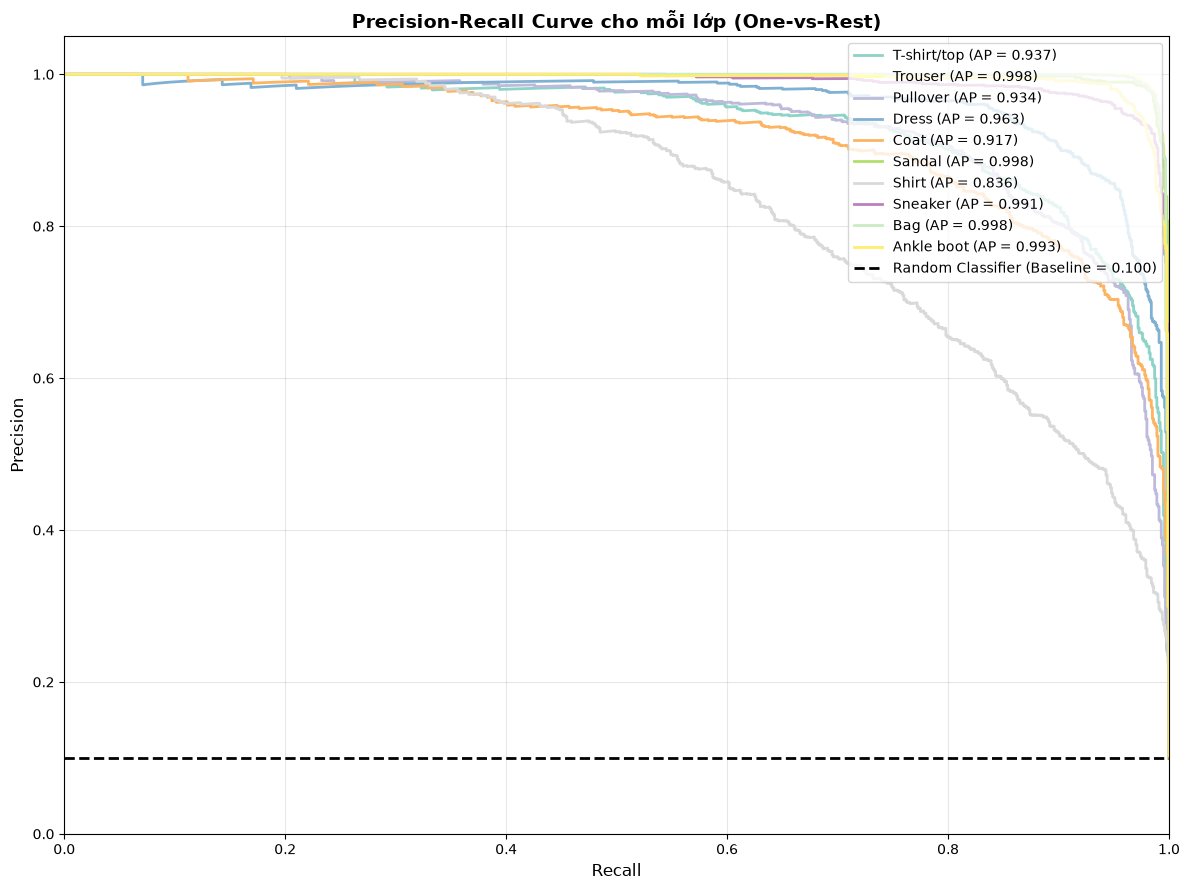


=== BƯỚC 13: PRECISION-RECALL CURVE - AVERAGE PRECISION SCORES ===
Lớp                  | AP Score    
-----------------------------------
T-shirt/top          | 0.9369      
Trouser              | 0.9982      
Pullover             | 0.9336      
Dress                | 0.9634      
Coat                 | 0.9165      
Sandal               | 0.9977      
Shirt                | 0.8365      
Sneaker              | 0.9906      
Bag                  | 0.9977      
Ankle boot           | 0.9935      
-----------------------------------
Trung bình (Mean)    | 0.9565      


In [11]:
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# ==========================================
# VẼ PRECISION-RECALL CURVE CHO MỖI LỚP
# ==========================================
n_classes = len(class_names)

# Chuyển đổi nhãn thành dạng one-hot encoding (nếu chưa)
y_bin = label_binarize(all_targets_roc, classes=range(n_classes))

plt.figure(figsize=(12, 9))

colors = plt.cm.Set3(np.linspace(0, 1, n_classes))
aps = []

for i in range(n_classes):
    # Tính Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
    
    # Tính Average Precision
    ap = average_precision_score(y_bin[:, i], all_probs[:, i])
    aps.append(ap)
    
    plt.plot(recall, precision, color=colors[i], lw=2,
             label=f'{class_names[i]} (AP = {ap:.3f})')

# Vẽ đường baseline (Random Classifier)
# Baseline precision = số lượng positive / tổng số mẫu
baseline_precision = np.mean([np.sum(y_bin[:, i]) for i in range(n_classes)]) / len(all_targets_roc)
plt.axhline(y=baseline_precision, color='k', linestyle='--', lw=2,
            label=f'Random Classifier (Baseline = {baseline_precision:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve cho mỗi lớp (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# In bảng Average Precision scores
mean_ap = np.mean(aps)
print("\n=== BƯỚC 13: PRECISION-RECALL CURVE - AVERAGE PRECISION SCORES ===")
print(f"{'Lớp':<20} | {'AP Score':<12}")
print("-" * 35)
for i, class_name in enumerate(class_names):
    print(f"{class_name:<20} | {aps[i]:<12.4f}")
print("-" * 35)
print(f"{'Trung bình (Mean)':<20} | {mean_ap:<12.4f}")


## Bước 14: Summary Table (Bảng tổng hợp kết quả)

- Tạo **bảng tổng hợp toàn diện** với các chỉ số hiệu năng cho từng lớp hàng hóa.
- Bảng bao gồm: **Precision**, **Recall**, **F1-Score**, **Support**, **AUC**, **Average Precision**.
- Visualize bảng kết quả dưới dạng heatmap để dễ dàng so sánh hiệu năng giữa các lớp.


=== BẢNG TỔNG HỢP KẾT QUẢ CHI TIẾT ===
        Class  Precision  Recall  F1-Score  Support      AUC  Average Precision
  T-shirt/top   0.839847  0.8810  0.859932     1000 0.991679           0.936880
      Trouser   0.991870  0.9760  0.983871     1000 0.999739           0.998194
     Pullover   0.796684  0.9130  0.850885     1000 0.990258           0.933617
        Dress   0.873596  0.9330  0.902321     1000 0.995733           0.963371
         Coat   0.829051  0.8390  0.833996     1000 0.989720           0.916531
       Sandal   0.976190  0.9840  0.980080     1000 0.999719           0.997661
        Shirt   0.838621  0.6080  0.704928     1000 0.971924           0.836461
      Sneaker   0.961105  0.9390  0.949924     1000 0.998952           0.990637
          Bag   0.974308  0.9860  0.980119     1000 0.999630           0.997711
   Ankle boot   0.950932  0.9690  0.959881     1000 0.999051           0.993457
Macro average   0.903221  0.9028  0.900594    10000 0.993640           0.956452


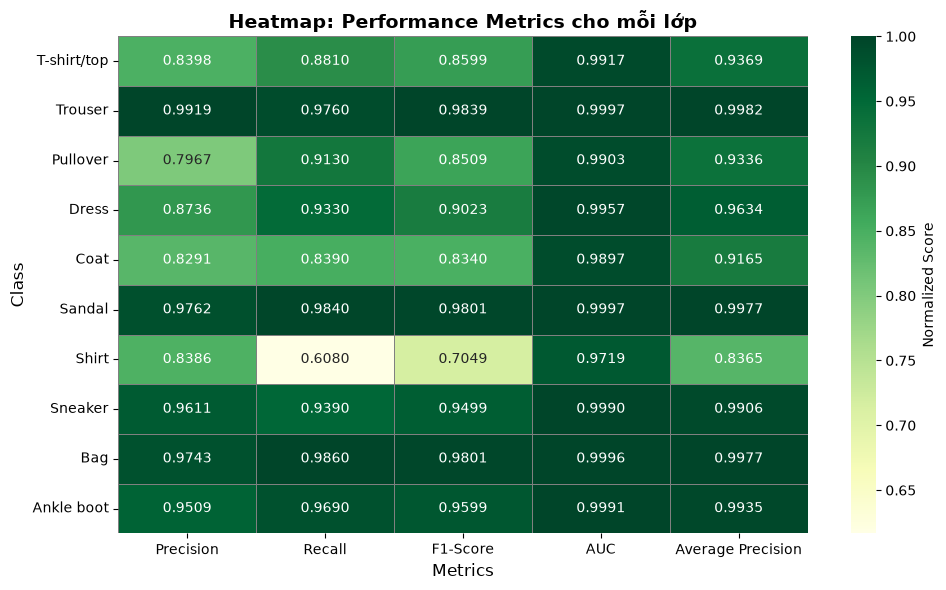

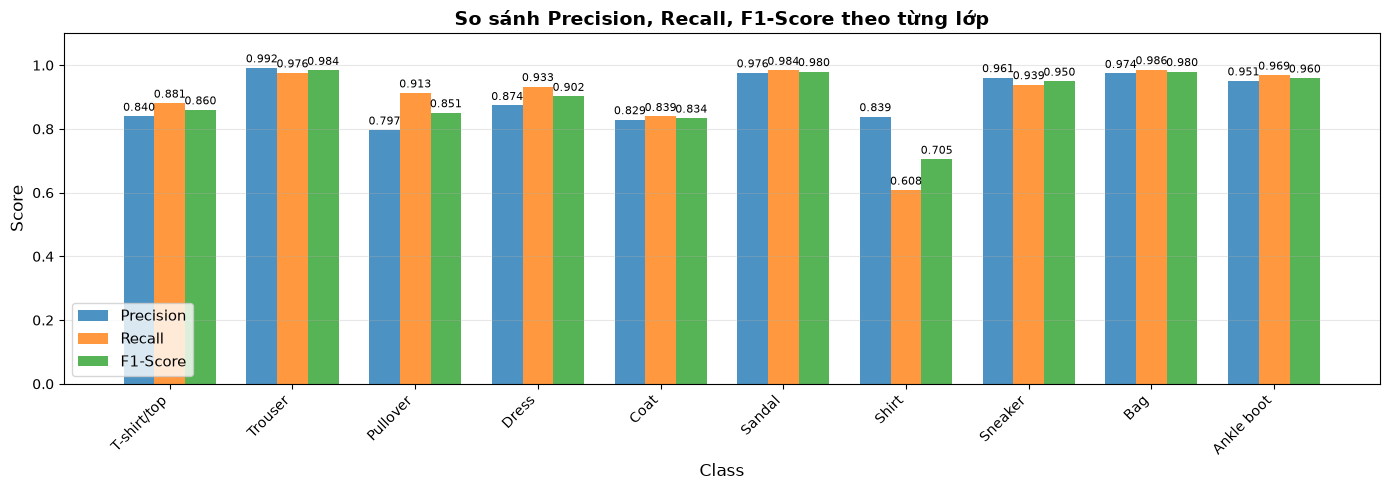

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# TẠO BẢNG TỔNG HỢP KẾT QUẢ CHI TIẾT
# ==========================================
precision, recall, f1, support = precision_recall_fscore_support(
    all_targets_roc, all_preds_cnn,
    labels=range(n_classes), average=None, zero_division=0
)

summary_data = {
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support,
    'AUC': aucs,
    'Average Precision': aps
}

df_summary = pd.DataFrame(summary_data)
avg_row = {
    'Class': 'Macro average',
    'Precision': precision.mean(),
    'Recall': recall.mean(),
    'F1-Score': f1.mean(),
    'Support': support.sum(),
    'AUC': np.mean(aucs),
    'Average Precision': np.mean(aps)
}
df_summary = pd.concat([df_summary, pd.DataFrame([avg_row])], ignore_index=True)

print("\n=== BẢNG TỔNG HỢP KẾT QUẢ CHI TIẾT ===")
print(df_summary.to_string(index=False))
df_summary.to_csv('model_performance_summary.csv', index=False)
print("\n-> Bảng đã được lưu vào file: model_performance_summary.csv")

# Support không phải là score, nên không đưa vào heatmap chuẩn hóa.
metric_columns = ['Precision', 'Recall', 'F1-Score', 'AUC', 'Average Precision']
df_heatmap = df_summary.iloc[:-1].set_index('Class')[metric_columns]
df_heatmap_norm = df_heatmap / df_heatmap.max(axis=0)

plt.figure(figsize=(10, 6))
sns.heatmap(
    df_heatmap_norm, annot=df_heatmap.round(4), fmt='.4f', cmap='YlGn',
    cbar_kws={'label': 'Normalized Score'}, linewidths=0.5, linecolor='gray'
)
plt.title('Heatmap: Performance Metrics cho mỗi lớp', fontsize=14, fontweight='bold')
plt.ylabel('Class', fontsize=12)
plt.xlabel('Metrics', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ SO SÁNH PRECISION, RECALL, F1-SCORE
# ==========================================
x = np.arange(len(class_names))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
ax.bar(x, recall, width, label='Recall', alpha=0.8)
ax.bar(x + width, f1, width, label='F1-Score', alpha=0.8)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('So sánh Precision, Recall, F1-Score theo từng lớp', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

plt.tight_layout()
plt.show()


## Bước 15: Misclassified Images (Ảnh bị dự đoán sai)

- Tìm ra các ảnh mà mô hình **dự đoán sai** (các mẫu bị phân loại nhầm).
- Hiển thị các **ảnh bị phân loại sai** cùng với:
  - **Nhãn thực tế (Ground Truth)**
  - **Nhãn dự đoán (Predicted Label)**
  - **Độ tin cậy (Confidence Score)**
- Phân tích các **lỗi thường gặp** giữa các cặp lớp để hiểu rõ những điểm yếu của mô hình.


=== PHÂN TÍCH ẢNH BỊ DỰ ĐOÁN SAI ===
- Tổng số mẫu đúng : 9,028
- Tổng số mẫu sai  : 972
- Tỷ lệ lỗi        : 9.72%


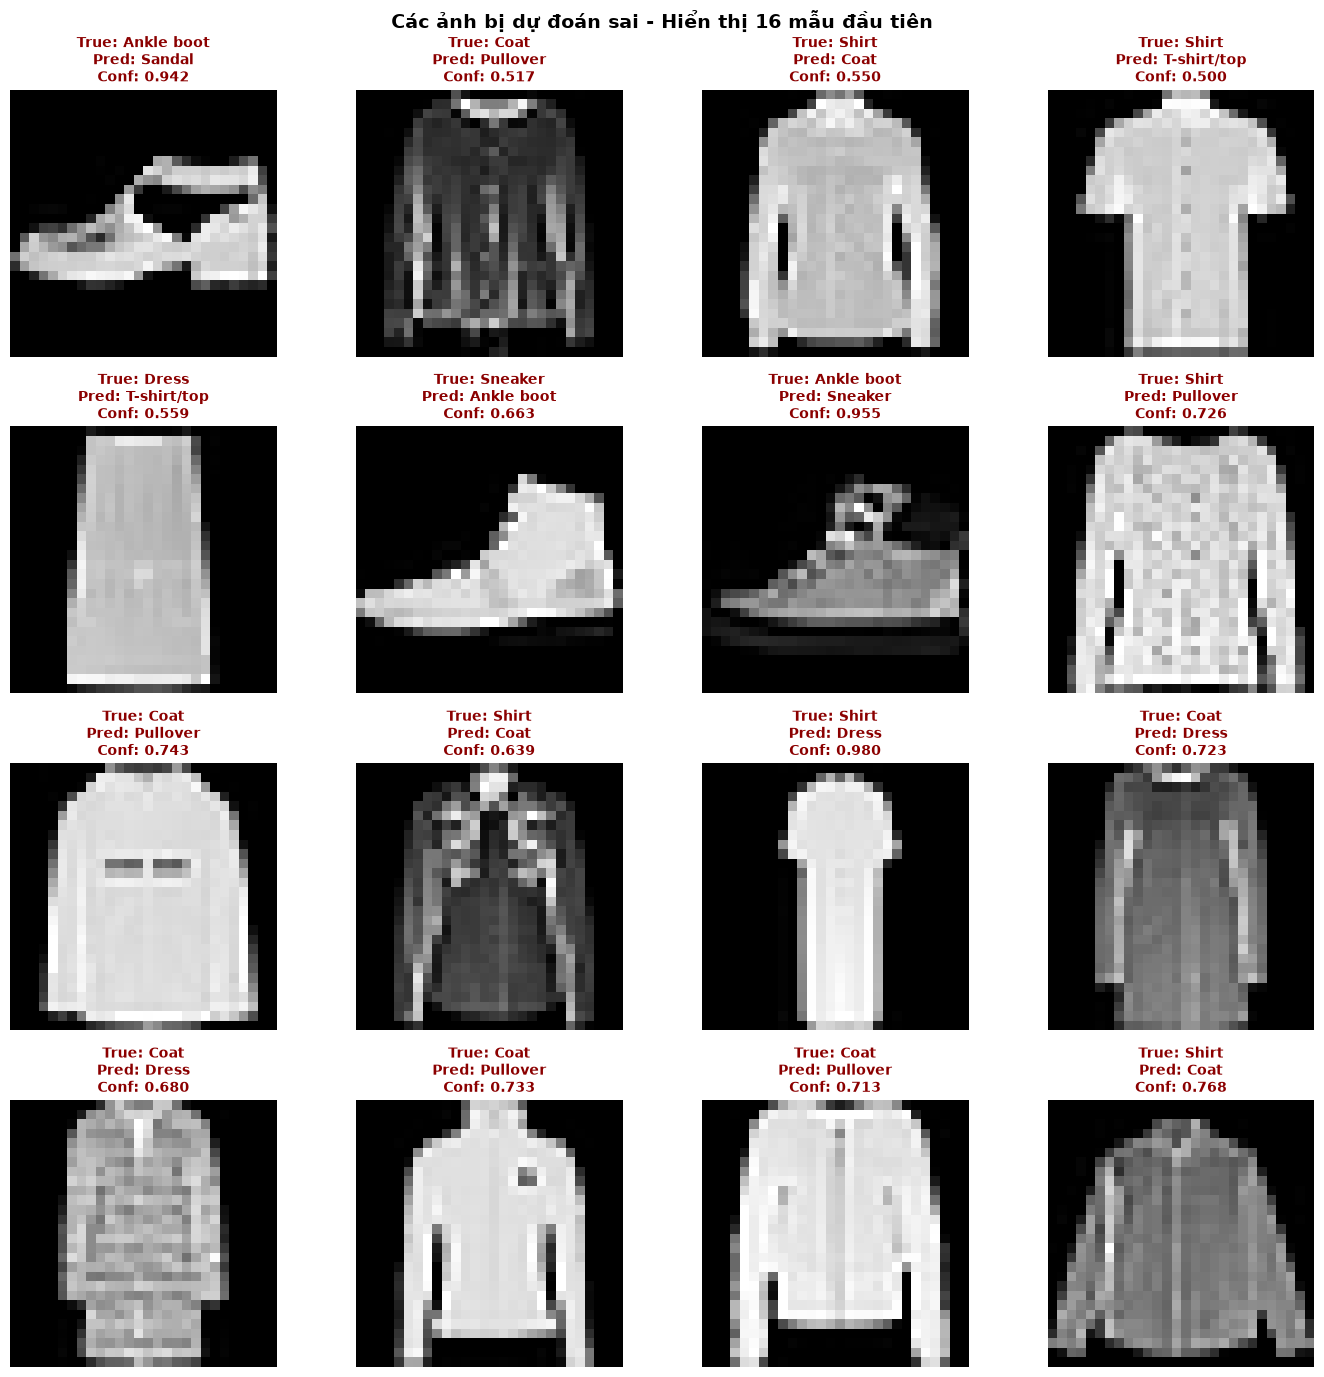

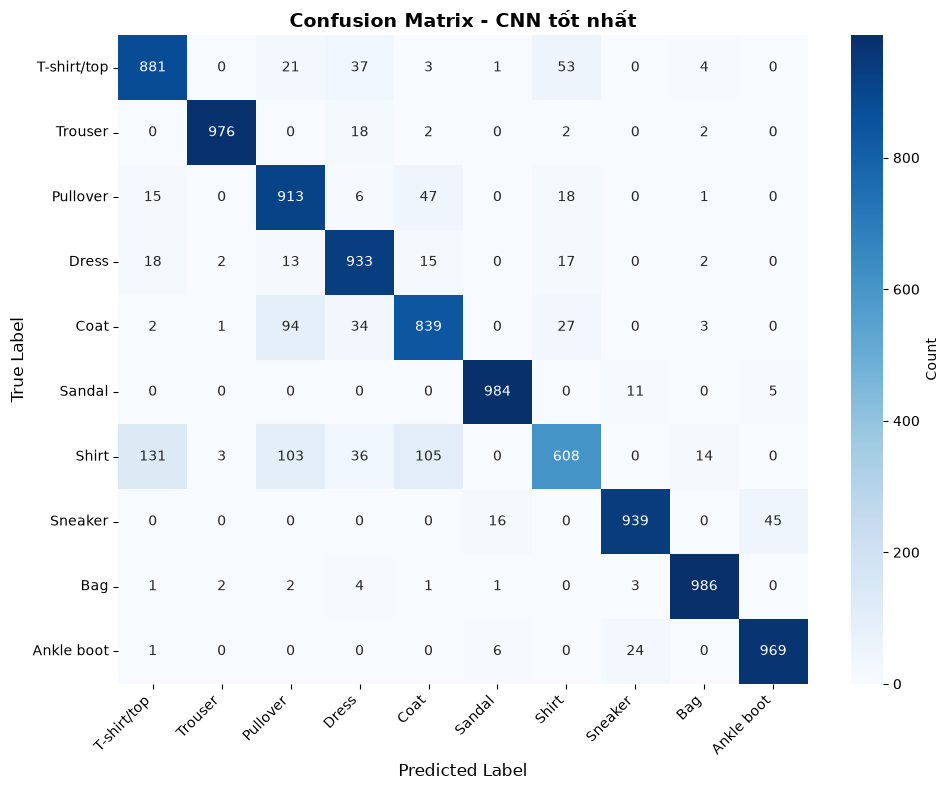


=== 10 CẶP LỚP BỊ NHẦM NHIỀU NHẤT ===
True Class      -> Predicted Class | Count | Percentage
-----------------------------------------------------------------
Shirt           -> T-shirt/top     | 131   | 13.10%
Shirt           -> Coat            | 105   | 10.50%
Shirt           -> Pullover        | 103   | 10.30%
Coat            -> Pullover        | 94    | 9.40%
T-shirt/top     -> Shirt           | 53    | 5.30%
Pullover        -> Coat            | 47    | 4.70%
Sneaker         -> Ankle boot      | 45    | 4.50%
T-shirt/top     -> Dress           | 37    | 3.70%
Shirt           -> Dress           | 36    | 3.60%
Coat            -> Dress           | 34    | 3.40%


In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# TÌM CÁC ẢNH BỊ DỰ ĐOÁN SAI CỦA CNN TỐT NHẤT
# ==========================================
misclassified_mask = all_preds_cnn != all_targets_roc
misclassified_indices = np.flatnonzero(misclassified_mask)

print("\n=== PHÂN TÍCH ẢNH BỊ DỰ ĐOÁN SAI ===")
print(f"- Tổng số mẫu đúng : {np.sum(np.logical_not(misclassified_mask)):,}")
print(f"- Tổng số mẫu sai  : {len(misclassified_indices):,}")
print(f"- Tỷ lệ lỗi        : {len(misclassified_indices) / len(all_targets_roc) * 100:.2f}%")

n_misclassified_to_show = min(16, len(misclassified_indices))
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.ravel()

for plot_index, image_index in enumerate(misclassified_indices[:n_misclassified_to_show]):
    image, true_label = test_dataset[image_index]
    predicted_label = all_preds_cnn[image_index]
    confidence = all_probs[image_index, predicted_label]
    image_np = image.cpu().numpy().squeeze()

    axes[plot_index].imshow(image_np, cmap='gray')
    axes[plot_index].set_title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[predicted_label]}\n"
        f"Conf: {confidence:.3f}",
        fontsize=10, fontweight='bold', color='darkred'
    )
    axes[plot_index].axis('off')

for plot_index in range(n_misclassified_to_show, len(axes)):
    axes[plot_index].axis('off')

plt.suptitle(
    f'Các ảnh bị dự đoán sai - Hiển thị {n_misclassified_to_show} mẫu đầu tiên',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ==========================================
# CONFUSION MATRIX VÀ CÁC CẶP LỚP DỄ NHẦM
# ==========================================
cm = confusion_matrix(all_targets_roc, all_preds_cnn, labels=range(n_classes))

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - CNN tốt nhất', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

errors = []
for true_index in range(n_classes):
    for predicted_index in range(n_classes):
        if true_index != predicted_index and cm[true_index, predicted_index] > 0:
            errors.append({
                'True': class_names[true_index],
                'Predicted': class_names[predicted_index],
                'Count': cm[true_index, predicted_index],
                'Percentage': cm[true_index, predicted_index] / cm[true_index].sum() * 100
            })

errors = sorted(errors, key=lambda item: item['Count'], reverse=True)
print("\n=== 10 CẶP LỚP BỊ NHẦM NHIỀU NHẤT ===")
print(f"{'True Class':<15} -> {'Predicted Class':<15} | Count | Percentage")
print("-" * 65)
for error in errors[:10]:
    print(
        f"{error['True']:<15} -> {error['Predicted']:<15} | "
        f"{error['Count']:<5} | {error['Percentage']:.2f}%"
    )
